In [36]:
import pandas as pd
import numpy as np
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, average_precision_score
from sklearn.feature_selection import RFECV, mutual_info_classif, VarianceThreshold
import matplotlib.pyplot as plt
import shap
import joblib

from src.preprocessing import load_data, merge_data, change_dtypes
from src.modeling import DefaultModel, HyperparameterTuner, model_evals, model_plots

## 1. Introduction

#### Goal:
To build a credit risk model to predict default and evaluate whether it is suitable for underwriting decisions. Given the class imbalance and business context, we focus on ranking performance (PR-AUC, KS) rather than accuracy.

## 2. Data Exploration

In [2]:
# Load the two datasets from the specified file paths
df1, df2 = load_data(['data/interview homework file A.csv', 'data/interview homework file B.csv'])

# Merge the two datasets on the 'ID' column after removing subcode '--xxx'
df = merge_data(df1, df2, on='ID')

# Sort by application date
df = change_dtypes(df, str_cols=['ID'], date_cols=['APPLICATION_DATE'])\
    .sort_values('APPLICATION_DATE')\
        .reset_index(drop=True)

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 13444 entries, 0 to 13443
Data columns (total 39 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID                13444 non-null  object        
 1   DEFAULT           13444 non-null  int64         
 2   CARDHLDR          13444 non-null  int64         
 3   SPENDING          10499 non-null  float64       
 4   APPLICATION_DATE  13444 non-null  datetime64[us]
 5   AGE               13444 non-null  float64       
 6   ACADMOS           13444 non-null  int64         
 7   ADEPCNT           13444 non-null  int64         
 8   MAJORDRG          13444 non-null  int64         
 9   MINORDRG          13444 non-null  int64         
 10  OWNRENT           13444 non-null  int64         
 11  MONTHLY_INCOME    13444 non-null  float64       
 12  SELFEMPL          13444 non-null  int64         
 13  MAJORDRG_lag1     13444 non-null  int64         
 14  MAJORDRG_lag2     13444 non-null 

### Two important columns in the dataset:

- CARDHLDR: 1 if the applicant is a cardholder, 0 otherwise.
- DEFAULT: 1 if the applicant defaulted on a previous loan, 0 otherwise.

In [3]:
print(df.groupby('CARDHLDR')['DEFAULT'].value_counts(normalize=True))
print('-'*50)
print(df['CARDHLDR'].value_counts(normalize=True))

CARDHLDR  DEFAULT
0         0          1.000000
1         0          0.905134
          1          0.094866
Name: proportion, dtype: float64
--------------------------------------------------
CARDHLDR
1    0.780943
0    0.219057
Name: proportion, dtype: float64


Looking at the distributions of these two columns, we have two main problems to deal with:
- Selection bias: We only have default data on approved applications (CARDHLDR=1), so we need to take that into account when building our model and interpreting the results. **So we will only use approved applications (CARDHLDR=1) for model training and evaluation as the initial step.**
- Class imbalance: The majority of approved applications are not defaulted (DEFAULT=0), so we have to consider techniques to handle class imbalance when building our model.

### Dealing with data quality issues:

**Potential data leakage issues:**
- SPENDING: This variable is only observed for approved applications, so it cannot be used as a predictor in our model.
- APPLICATION_DATE: When data splitting for training and testing, we need to ensure that we are not using future information.

**Dropping problematic columns:**
- birth_year is not directly useful, and we can derive age at application from it, so we will drop birth_year.
- ANNUAL_INCOME and MONTHLY_INCOME are highly correlated, so we will drop ANNUAL_INCOME.

In [4]:
print('Correlation between ANNUAL_INCOME and MONTHLY_INCOME:')
print('-' * 50)
print(df[['ANNUAL_INCOME', 'MONTHLY_INCOME']].corr())
df.drop(columns=['ANNUAL_INCOME', 'SPENDING'], inplace=True)

Correlation between ANNUAL_INCOME and MONTHLY_INCOME:
--------------------------------------------------
                ANNUAL_INCOME  MONTHLY_INCOME
ANNUAL_INCOME             1.0             1.0
MONTHLY_INCOME            1.0             1.0


- AGE is the current age of the applicant, but we need the age at the time of application, so we will drop AGE and derive AGE_AT_APPLICATION from APPLICATION_DATE and birth_year. Since 18 is the minimum legal age for credit card applications, we will also clip the derived age at a minimum of 18 to avoid any data quality issues.

In [5]:
df['AGE_AT_APPLICATION'] = np.clip(df['APPLICATION_DATE'].dt.year - df['birth_year'], a_min=18, a_max=None).values

- Columns with low variance:

In [6]:
selector = VarianceThreshold(threshold=0.01)
selector.fit(df.drop(columns=['ID', 'APPLICATION_DATE', 'DEFAULT']))
low_variance_cols = df.drop(columns=['ID', 'APPLICATION_DATE', 'DEFAULT']).columns[~selector.get_support()]
print(f"Columns with low variance: {list(low_variance_cols)}")
df.drop(columns=low_variance_cols, inplace=True)

Columns with low variance: ['MAJORDRG_lag4', 'MAJORDRG_lag5', 'MAJORDRG_lag6', 'MAJORDRG_lag7', 'MAJORDRG_lag8', 'MAJORDRG_lag9', 'MAJORDRG_lag10', 'MAJORDRG_lag11', 'MINORDRG_lag2', 'MINORDRG_lag3', 'MINORDRG_lag4', 'MINORDRG_lag5', 'MINORDRG_lag6', 'MINORDRG_lag7', 'MINORDRG_lag8', 'MINORDRG_lag9', 'MINORDRG_lag10', 'MINORDRG_lag11']


#### When was the data observed??

Last application date is 2023-12-31. If the data was observed at this point, then we shouldn't use the applicants from last year because DEFAULT is not completely observed (12 months) for them. But looking at current age, it seems that the data was observed at the end of 2024, so we can use all the data for model training and evaluation.

In [7]:
df['APPLICATION_DATE'].max()

Timestamp('2023-12-01 00:00:00')

In [8]:
observed_year = df[['AGE', 'birth_year']].apply(lambda x: x['AGE'] + x['birth_year'], axis=1)
print((observed_year - df['APPLICATION_DATE'].dt.year).min())

1.083332100000007


In [9]:
df.drop(columns=['birth_year', 'AGE'], inplace=True)

In [10]:
df.columns

Index(['ID', 'DEFAULT', 'CARDHLDR', 'APPLICATION_DATE', 'ACADMOS', 'ADEPCNT',
       'MAJORDRG', 'MINORDRG', 'OWNRENT', 'MONTHLY_INCOME', 'SELFEMPL',
       'MAJORDRG_lag1', 'MAJORDRG_lag2', 'MAJORDRG_lag3', 'MAJORDRG_lag12',
       'MINORDRG_lag1', 'MINORDRG_lag12', 'AGE_AT_APPLICATION'],
      dtype='object')

## 3. Feature Engineering

- We will create few new features based on the existing ones:
    - INCOME_PER_DEP: Monthly income divided by the number of dependents to get a sense of financial burden.
    - INCOME_LOG: Log transformation of monthly income to reduce skewness. There is a slight skew in the income distribution, so log transformation can help to normalize it.
    - ACADMOS_LOG: ACADMOS is highly right-skewed, so we will apply a log transformation to it as well.
    - MAJORDRG_MAX and MINORDRG_MAX: Maximum major and minor derogatory counts in the past 12 months to capture the worst behavior in the recent history.
    - MAJORDRG_AVG_NONZERO and MINORDRG_AVG_NONZERO: Average major and minor derogatory counts in the past 12 months, excluding months with zero counts, to capture the average severity of derogatory behavior when it occurs.

In [11]:
df['INCOME_PER_DEP'] = df['MONTHLY_INCOME'] / (df['ADEPCNT'] + 1)
df['INCOME_LOG'] = np.log1p(df['MONTHLY_INCOME'])
df['ACADMOS_LOG'] = np.log1p(df['ACADMOS'])
df['MAJORDRG_MAX'] = df[[f'MAJORDRG_lag{i}' for i in range(1, 13) if f'MAJORDRG_lag{i}' in df.columns]].max(axis=1)
df['MINORDRG_MAX'] = df[[f'MINORDRG_lag{i}' for i in range(1, 13) if f'MINORDRG_lag{i}' in df.columns]].max(axis=1)
df['MAJORDRG_AVG_NONZERO'] = df[[f'MAJORDRG_lag{i}' for i in range(1, 13) if f'MAJORDRG_lag{i}' in df.columns]].apply(lambda row: [row[f'MAJORDRG_lag{i}'] for i in range(1, 13) if f'MAJORDRG_lag{i}' in df.columns], axis=1).apply(lambda x: sum(x) / len([i for i in x if i > 0]) if any(i > 0 for i in x) else 0)
df['MINORDRG_AVG_NONZERO'] = df[[f'MINORDRG_lag{i}' for i in range(1, 13) if f'MINORDRG_lag{i}' in df.columns]].apply(lambda row: [row[f'MINORDRG_lag{i}'] for i in range(1, 13) if f'MINORDRG_lag{i}' in df.columns], axis=1).apply(lambda x: sum(x) / len([i for i in x if i > 0]) if any(i > 0 for i in x) else 0)

df.drop(columns=['MONTHLY_INCOME', 'ACADMOS'], inplace=True) # Drop zero variance columns and original MONTHLY_INCOME after feature engineering

In [12]:
print(df.head())

       ID  DEFAULT  CARDHLDR APPLICATION_DATE  ADEPCNT  MAJORDRG  MINORDRG  \
0  524852        0         0       2021-01-01        1         0         0   
1  942301        0         1       2021-01-01        2         0         0   
2  881059        0         0       2021-01-01        0         0         0   
3  769814        0         1       2021-01-01        0         2         2   
4  927528        0         1       2021-01-01        2         0         0   

   OWNRENT  SELFEMPL  MAJORDRG_lag1  ...  MINORDRG_lag1  MINORDRG_lag12  \
0        0         1              0  ...              0               0   
1        1         0              0  ...              0               0   
2        0         0              0  ...              0               0   
3        0         0              1  ...              1               1   
4        1         0              0  ...              0               0   

   AGE_AT_APPLICATION  INCOME_PER_DEP  INCOME_LOG  ACADMOS_LOG  MAJORDRG_MAX  \


#### Mutual information analysis:
- We will calculate mutual information between each feature and the target variable (DEFAULT) and CARDHLDR:

In [13]:
from sklearn.feature_selection import mutual_info_classif

mi_default = mutual_info_classif(df.drop(columns=['ID', 'APPLICATION_DATE', 'DEFAULT', 'CARDHLDR']), df['DEFAULT'], discrete_features='auto', random_state=42)
mi_cardhldr = mutual_info_classif(df.drop(columns=['ID', 'APPLICATION_DATE', 'DEFAULT', 'CARDHLDR']), df['CARDHLDR'], discrete_features='auto', random_state=42)
mi_default_series = pd.Series(mi_default, index=df.drop(columns=['ID', 'APPLICATION_DATE', 'DEFAULT', 'CARDHLDR']).columns).sort_values(ascending=False)
mi_cardhldr_series = pd.Series(mi_cardhldr, index=df.drop(columns=['ID', 'APPLICATION_DATE', 'DEFAULT', 'CARDHLDR']).columns).sort_values(ascending=False)
print('-' * 50)
print("Mutual Information Scores for DEFAULT:")
print('-' * 50)
print(mi_default_series[mi_default_series > 0])
print('-'*50)
print("Mutual Information Scores for CARDHLDR:")
print('-' * 50)
print(mi_cardhldr_series[mi_cardhldr_series > 0])
print('-'*50)

--------------------------------------------------
Mutual Information Scores for DEFAULT:
--------------------------------------------------
SELFEMPL                0.005859
MINORDRG_lag12          0.004597
MAJORDRG_lag12          0.004332
MAJORDRG                0.003644
INCOME_LOG              0.003150
MAJORDRG_lag1           0.002787
AGE_AT_APPLICATION      0.002650
INCOME_PER_DEP          0.002618
MINORDRG                0.002131
ACADMOS_LOG             0.001620
MINORDRG_AVG_NONZERO    0.001618
ADEPCNT                 0.000567
MINORDRG_MAX            0.000482
dtype: float64
--------------------------------------------------
Mutual Information Scores for CARDHLDR:
--------------------------------------------------
MAJORDRG                0.015582
MAJORDRG_AVG_NONZERO    0.015545
MAJORDRG_MAX            0.010189
MAJORDRG_lag1           0.008986
MAJORDRG_lag12          0.007356
MAJORDRG_lag2           0.006277
ADEPCNT                 0.005293
MINORDRG                0.004099
ACADMOS_L

The mutual information scores above are pretty weak, so we will rely on the model to capture complex relationships between features and the target variable and see if it can improve performance.

## 4. Model Building and Evaluation

#### Plan:
1. Model Selection
    - Train logistic regression and XGBoost
    - Compare ROC AUC, PR AUC, KS
    - Select best model → XGBoost (with good enough performance for deployment)

2. Propensity Model for Selection Bias
    - Target: CARDHLDR (approved vs rejected)
    - Features: application-time variables available for all 13k applicants
    - Goal: estimate approval probability for each approved applicant

3. IPW Adjustment
    - $\rm{Weight} = \dfrac{1}{P(\rm{approved} \mid \rm{features})}$
    - Retrain chosen model with these weights
    - Compare weighted vs unweighted metrics

4. Limitations:
    - If propensity model is weak $\rightarrow$ weights unreliable

- We will use Logistic Regression and XGBoost as our models to predict DEFAULT.
- We will use APPLICATION_DATE to split the data into training and testing sets, ensuring that we are not using future information for training.
- We will evaluate the models using AUC-ROC and AUC-PR metrics, which are appropriate for imbalanced classification problems.

### Train-test split:

In [14]:
X = df.drop(columns=['CARDHLDR', 'ID', 'DEFAULT'])
y = df['DEFAULT']
approved_mask = df['CARDHLDR']== 1


cutoff_date = df[df['CARDHLDR']==1]['APPLICATION_DATE'].quantile(0.85)

train_mask = (df['APPLICATION_DATE'] <= cutoff_date) & (approved_mask)
test_mask = (df['APPLICATION_DATE'] > cutoff_date) & (approved_mask)

X_train, y_train = X[train_mask].drop(columns=['APPLICATION_DATE']), y[train_mask]
X_test, y_test = X[test_mask].drop(columns=['APPLICATION_DATE']), y[test_mask]

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)
print('-'*50)
print('Training set default rate:', y_train.mean())
print('Test set default rate:', y_test.mean())
print('Test set defaults:', y_test.sum())
print('-'*50)
print('Training set cols:', X_train.columns)

Training set shape: (9029, 19)
Test set shape: (1470, 19)
--------------------------------------------------
Training set default rate: 0.09535939749695425
Test set default rate: 0.09183673469387756
Test set defaults: 135
--------------------------------------------------
Training set cols: Index(['ADEPCNT', 'MAJORDRG', 'MINORDRG', 'OWNRENT', 'SELFEMPL',
       'MAJORDRG_lag1', 'MAJORDRG_lag2', 'MAJORDRG_lag3', 'MAJORDRG_lag12',
       'MINORDRG_lag1', 'MINORDRG_lag12', 'AGE_AT_APPLICATION',
       'INCOME_PER_DEP', 'INCOME_LOG', 'ACADMOS_LOG', 'MAJORDRG_MAX',
       'MINORDRG_MAX', 'MAJORDRG_AVG_NONZERO', 'MINORDRG_AVG_NONZERO'],
      dtype='object')


### Logistic Regression:
- We first standardize the features and then fit a logistic regression model on the training data.
- We evaluate the model on the test set and calculate AUC-ROC and PR-AUC.

In [15]:
scaler = StandardScaler()
cols_to_scale = ['AGE_AT_APPLICATION', 'ACADMOS_LOG', 'ADEPCNT', 'INCOME_PER_DEP', 'INCOME_LOG', 'MAJORDRG', 'MINORDRG',
                 'MAJORDRG_MAX', 'MINORDRG_MAX', 'MAJORDRG_AVG_NONZERO', 
                 'MINORDRG_AVG_NONZERO']
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
X[cols_to_scale] = scaler.transform(X[cols_to_scale])

clf = DefaultModel(model_type='logistic', C=0.03, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred_proba = clf.predict_proba(X_test)[:, 1]
ks_stat, p_value, roc_auc, pr_auc = model_evals(y_test, y_pred_proba)
print(f"Logistic Regression - AUC-ROC: {roc_auc:.2f}, PR-AUC: {pr_auc:.2f}")
print(f"Logistic Regression - training AUC-ROC: {roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1]):.2f}, training PR-AUC: {average_precision_score(y_train, clf.predict_proba(X_train)[:, 1]):.2f}")
print(f"KS Statistic: {ks_stat:.2f}, p-value: {p_value:.2f}")

Logistic Regression - AUC-ROC: 0.55, PR-AUC: 0.11
Logistic Regression - training AUC-ROC: 0.56, training PR-AUC: 0.11
KS Statistic: 0.11, p-value: 0.12


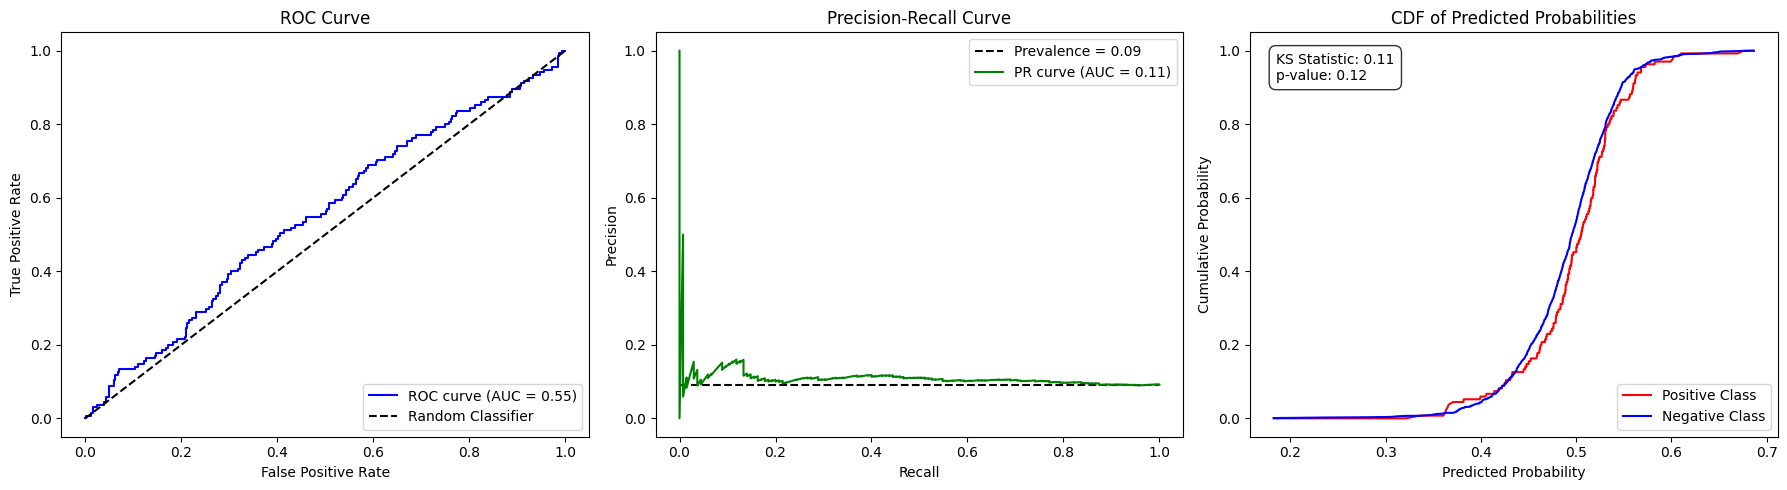

In [16]:
model_plots(y_test, y_pred_proba)

#### Tuning:

In [17]:
tuner = HyperparameterTuner(
    time_budget=60, 
    metric='roc_auc', 
    estimators = ['lrl1', 'lrl2'], 
    early_stop=True, 
    verbose=1, 
    eval_method='holdout', 
    X_val=X_test, 
    y_val=y_test,
    class_weight='balanced',
    )

tuner.fit(X_train, y_train)
best_model = tuner.best_estimator()
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
ks_stat, p_value, roc_auc, pr_auc = model_evals(y_test, y_pred_proba)
print(f"Best config: {tuner.best_config()}")
print(f"XGBoost - AUC-ROC: {roc_auc:.2f}, PR-AUC: {pr_auc:.2f}")
print(f"XGBoost - training AUC-ROC: {roc_auc_score(y_train, best_model.predict_proba(X_train)[:, 1]):.2f}, training PR-AUC: {average_precision_score(y_train, best_model.predict_proba(X_train)[:, 1]):.2f}")
print(f"KS Statistic: {ks_stat:.2f}, p-value: {p_value:.2f}")

Best config: {'C': np.float64(11.617978703547312), 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': -1, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
XGBoost - AUC-ROC: 0.55, PR-AUC: 0.11
XGBoost - training AUC-ROC: 0.56, training PR-AUC: 0.11
KS Statistic: 0.12, p-value: 0.07


### XGBoost:

In [ ]:
params = {
    'n_estimators': 30,
    'max_depth': 4,
    'max_leaves': 6,
    'min_child_weight': 0.4,
    'learning_rate': 0.01,
    'subsample': 0.7,
    'colsample_bylevel': 0.75,
    'colsample_bytree': 1.0,
    'reg_alpha': 0.1,
    'reg_lambda': 0.4
}

model = DefaultModel(model_type='xgboost', **params)
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)[:, 1]
ks_stat, p_value, roc_auc, pr_auc = model_evals(y_test, y_pred_proba)
print(f"XGBoost - TEST AUC-ROC: {roc_auc:.2f}, PR-AUC: {pr_auc:.2f}")
print(f"XGBoost - TRAIN AUC-ROC: {roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]):.2f}, PR-AUC: {average_precision_score(y_train, model.predict_proba(X_train)[:, 1]):.2f}")
print(f"KS Statistic: {ks_stat:.2f}, p-value: {p_value:.2f}")

XGBoost - TEST AUC-ROC: 0.54, PR-AUC: 0.10
XGBoost - TRAIN AUC-ROC: 0.59, PR-AUC: 0.14
KS Statistic: 0.12, p-value: 0.05


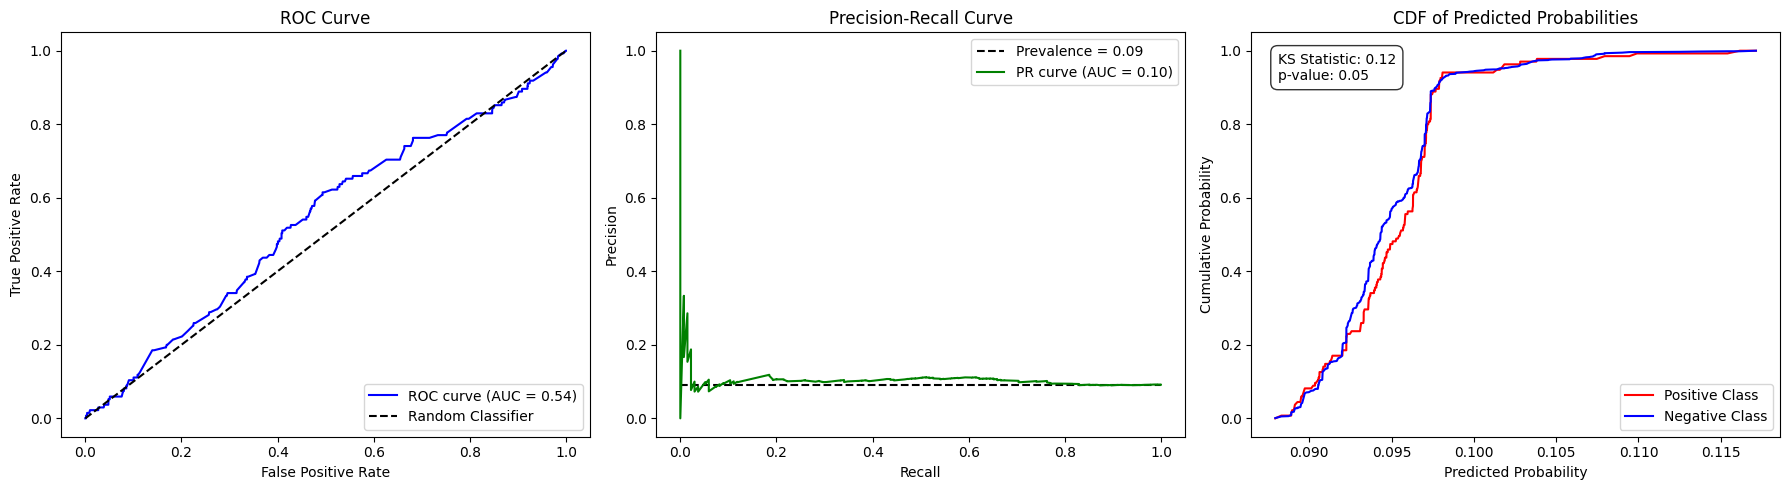

In [19]:
model_plots(y_test, y_pred_proba)

#### Tuning:

In [20]:
tuner = HyperparameterTuner(
    time_budget=135, 
    metric='roc_auc', 
    estimators = ['xgboost'], 
    early_stop=True, 
    verbose=1, 
    split_type='auto', 
    X_val=X_test, 
    y_val=y_test,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    )

tuner.fit(X_train, y_train)
best_model = tuner.best_estimator()
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

ks_stat, p_value, roc_auc, pr_auc = model_evals(y_test, y_pred_proba)

#print(f"Best config: {tuner.best_config()}")
print(f"XGBoost - AUC-ROC: {roc_auc:.2f}, PR-AUC: {pr_auc:.2f}")
print(f"XGBoost - TRAIN AUC-ROC: {roc_auc_score(y_train, best_model.predict_proba(X_train)[:, 1]):.2f}, PR-AUC: {average_precision_score(y_train, best_model.predict_proba(X_train)[:, 1]):.2f}")
print(f"KS Statistic: {ks_stat:.2f}, p-value: {p_value:.2f}")

XGBoost - AUC-ROC: 0.58, PR-AUC: 0.12
XGBoost - TRAIN AUC-ROC: 0.66, PR-AUC: 0.20
KS Statistic: 0.15, p-value: 0.01


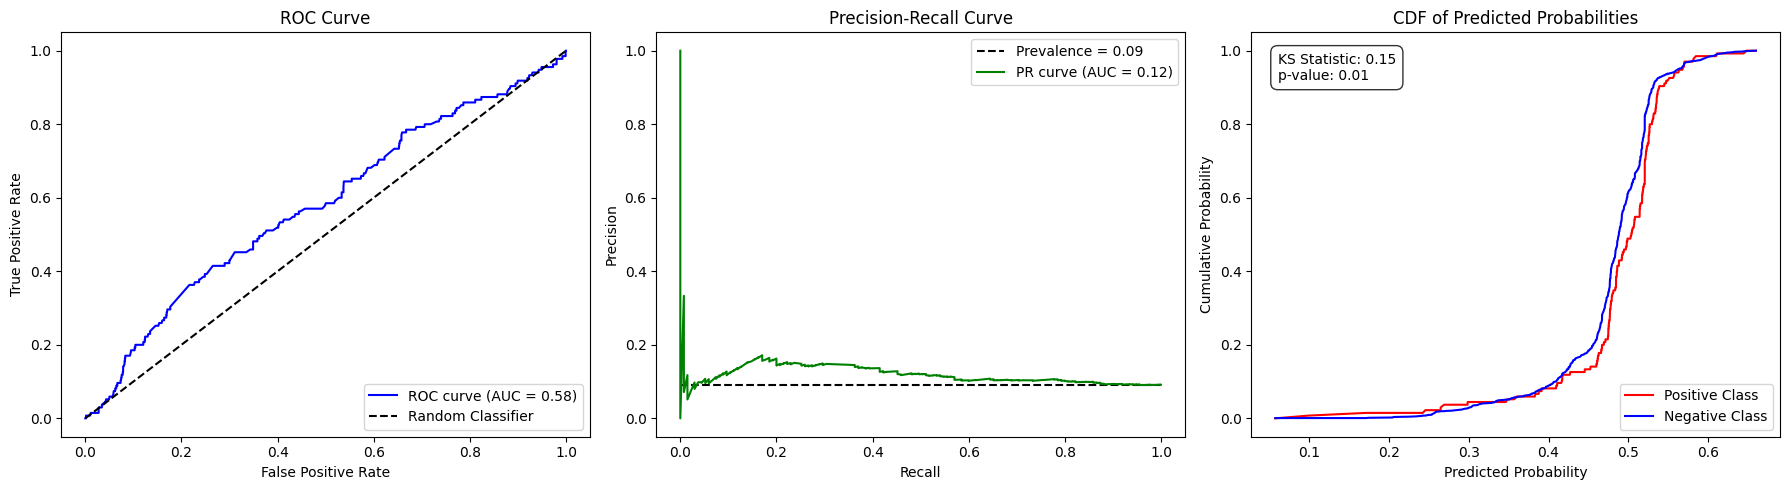

In [ ]:
model_plots(y_test, y_pred_proba)

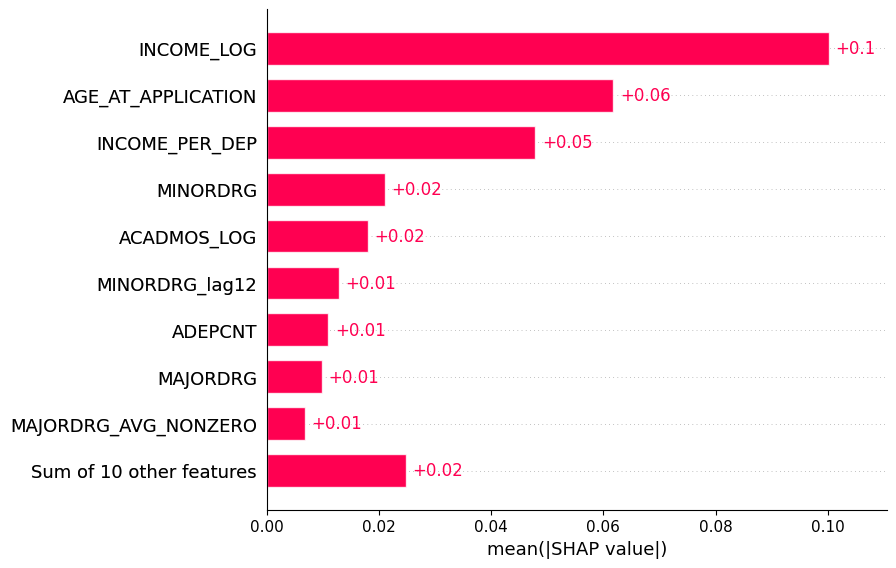

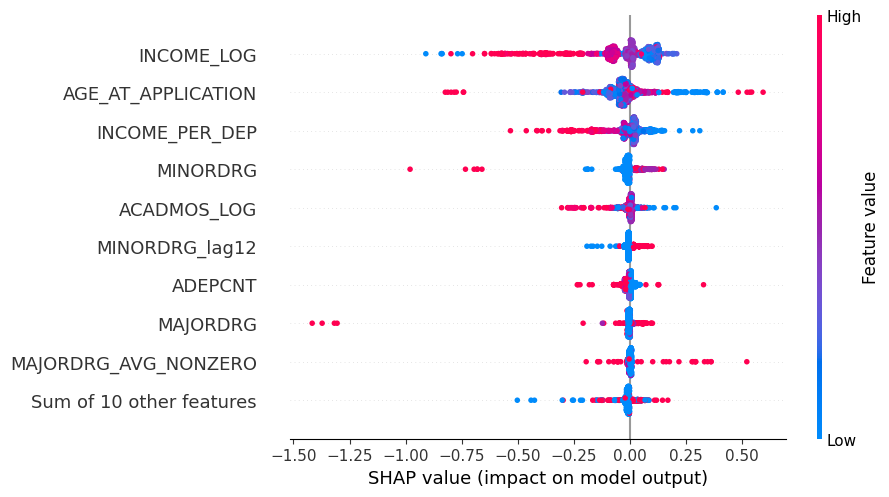

In [ ]:
explainer = shap.Explainer(tuner.best_estimator().estimator)
shap_values = explainer(X_test)

X_test_shap_values = pd.DataFrame(shap_values.values, columns=X_test.columns)

shap.plots.bar(shap_values, max_display=10)
shap.plots.beeswarm(shap_values, max_display=10)

In [ ]:
best_features_series = pd.Series(np.abs(shap_values.values).mean(0), index=X_test.columns).sort_values(ascending=False)[:4]
best_features = best_features_series.index.tolist()

tuner = HyperparameterTuner(
    time_budget=30, 
    metric='roc_auc', 
    estimators = ['xgboost'], 
    early_stop=True, 
    verbose=1, 
    split_type='auto', 
    X_val=X_test, 
    y_val=y_test,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    )

tuner.fit(X_train[best_features], y_train)
best_model = tuner.best_estimator()
y_pred_proba = best_model.predict_proba(X_test[best_features])[:, 1]

ks_stat, p_value, roc_auc, pr_auc = model_evals(y_test, y_pred_proba)

#print(f"Best config: {tuner.best_config()}")
print(f"XGBoost - AUC-ROC: {roc_auc:.2f}, PR-AUC: {pr_auc:.2f}")
print(f"XGBoost - TRAIN AUC-ROC: {roc_auc_score(y_train, best_model.predict_proba(X_train[best_features])[:, 1]):.2f}, PR-AUC: {average_precision_score(y_train, best_model.predict_proba(X_train[best_features])[:, 1]):.2f}")
print(f"KS Statistic: {ks_stat:.2f}, p-value: {p_value:.2f}")

XGBoost - AUC-ROC: 0.58, PR-AUC: 0.12
XGBoost - TRAIN AUC-ROC: 0.62, PR-AUC: 0.15
KS Statistic: 0.16, p-value: 0.00


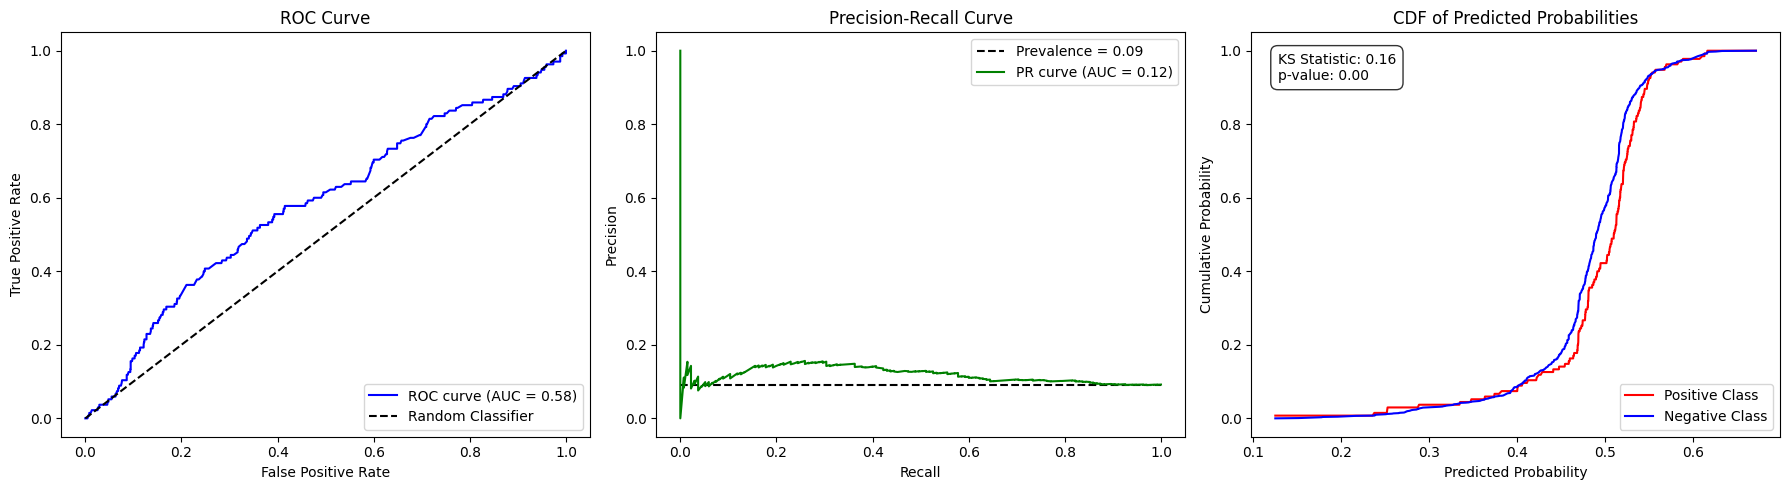

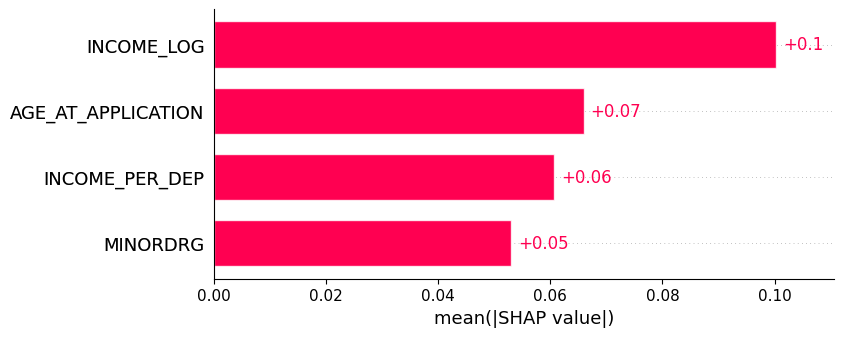

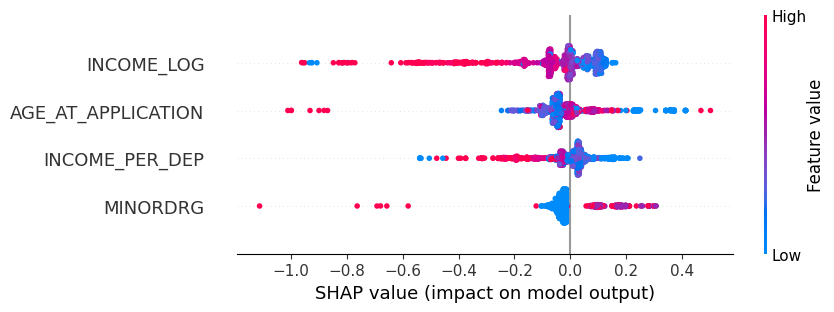

In [30]:
model_plots(y_test, y_pred_proba)
explainer = shap.Explainer(tuner.best_estimator().estimator)
shap_values = explainer(X_test[best_features])

X_test_shap_values = pd.DataFrame(shap_values.values, columns=best_features)

shap.plots.bar(shap_values, max_display=10)
shap.plots.beeswarm(shap_values, max_display=10)

In [37]:
joblib.dump(tuner.best_estimator(), 'best_model.joblib')

['best_model.joblib']

## 5. Conclusion 

- As we can see from the results, the AUC-ROC barely touches 0.58 (even after accounting for the slight overfitting), which is borderline. 
- We also looked at the PR-AUC, which is a more informative metric in imbalanced datasets, and it is around 0.12 which is a $\frac{0.12-0.09}{0.09} = 33\%$ improvement over the baseline, but still not good enough to be used in production.
- The KS statistic is modest around 0.16, which indicates that the model has some discriminatory power. 
- This is consistent with the weak mutual information scores we observed during previous steps, which suggest that the features we have are not very predictive of the target variable (DEFAULT).
- To get better performance, we would need to either get data with more predictive features or more data to capture complex relationships better.


So overall, while we see some improvement over the baseline, the model's performance is not strong enough to be used for making approval decisions in production. **The model in its current state is not good enough to be used for making approval decisions in production.**

But because it has some discriminatory power, it could be used as a risk scoring model, and prioritize applicants for manual review.